In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
df=pd.read_csv("Ledger_dataset (2).csv")

In [25]:
df

,ledger_id,transaction_id,date,account_name,transaction_type,debit_amount,credit_amount,tax_amount,discount_amount,balance
0,1,TXN1001,2026-08-02,Purchases,Credit,7770.0,1360.0,3872.0,1638.0,7265.0
1,2,TXN1002,2026-08-03,Rent,Debit,966.0,14026.0,4526.0,1482.0,15423.0
2,3,TXN1003,2026-08-04,Salary,Credit,12136.0,11863.0,3019.0,130.0,2685.0
3,4,TXN1004,2026-08-05,Utilities,Debit,NaN,11083.0,2533.0,1215.0,6051.0
4,5,TXN1005,2026-08-06,Office Supplies,Credit,6920.0,1684.0,4655.0,21.0,7396.0
5,6,TXN1006,2026-08-07,Travel,Debit,13535.0,11596.0,NaN,1082.0,19942.0
6,7,TXN1007,2026-08-08,Bank Charges,Credit,8349.0,2547.0,2847.0,975.0,27382.0
7,8,TXN1008,2026-08-09,Sales,Debit,689.0,3234.0,3105.0,562.0,2899.0
8,9,TXN1009,2026-08-10,Purchases,Credit,8234.0,NaN,1628.0,646.0,28464.0
9,10,TXN1010,2026-08-11,Rent,Debit,5893.0,11127.0,700.0,2363.0,11253.0


In [26]:
df.shape

(53, 10)

In [27]:
df.tail()

,ledger_id,transaction_id,date,account_name,transaction_type,debit_amount,credit_amount,tax_amount,discount_amount,balance
48,49,TXN1049,2026-08-22,Purchases,Credit,6787.0,9300.0,3372.0,1147.0,NaN
49,50,TXN1050,2026-08-23,Rent,Debit,12089.0,3011.0,1894.0,659.0,3811.0
50,7,TXN1007,2026-08-08,Bank Charges,Credit,8349.0,2547.0,2847.0,975.0,27382.0
51,21,TXN1021,2026-08-22,Office Supplies,Credit,9184.0,7708.0,2162.0,64.0,17216.0
52,37,TXN1037,2026-08-10,Office Supplies,Credit,14196.0,14188.0,1406.0,2680.0,28251.0


In [28]:
df.head()

,ledger_id,transaction_id,date,account_name,transaction_type,debit_amount,credit_amount,tax_amount,discount_amount,balance
0,1,TXN1001,2026-08-02,Purchases,Credit,7770.0,1360.0,3872.0,1638.0,7265.0
1,2,TXN1002,2026-08-03,Rent,Debit,966.0,14026.0,4526.0,1482.0,15423.0
2,3,TXN1003,2026-08-04,Salary,Credit,12136.0,11863.0,3019.0,130.0,2685.0
3,4,TXN1004,2026-08-05,Utilities,Debit,NaN,11083.0,2533.0,1215.0,6051.0
4,5,TXN1005,2026-08-06,Office Supplies,Credit,6920.0,1684.0,4655.0,21.0,7396.0


In [29]:
df.describe()

,ledger_id,debit_amount,credit_amount,tax_amount,discount_amount,balance
count,53.000000,50.000000,50.000000,50.000000,50.000000,50.000000
mean,25.283019,8081.160000,8574.260000,2593.020000,1449.960000,16174.020000
std,14.481258,3616.265552,4110.481181,1275.951338,824.605904,8620.857336
min,1.000000,689.000000,706.000000,261.000000,21.000000,1663.000000
25%,13.000000,5927.250000,6055.750000,1665.500000,872.000000,8451.250000
50%,25.000000,7991.000000,8809.000000,2672.000000,1510.000000,17216.000000
75%,37.000000,10374.000000,11858.250000,3432.000000,2054.750000,24399.250000
max,50.000000,14934.000000,14377.000000,4975.000000,2977.000000,29673.000000


In [30]:
df.columns

Index(['ledger_id', 'transaction_id', 'date', 'account_name',
       'transaction_type', 'debit_amount', 'credit_amount', 'tax_amount',
       'discount_amount', 'balance'],
      dtype='object')

In [31]:
df.isnull().sum()

ledger_id           0
transaction_id      0
date                0
account_name        0
transaction_type    0
debit_amount        3
credit_amount       3
tax_amount          3
discount_amount     3
balance             3
dtype: int64

In [33]:
df["debit_amount"]=df["debit_amount"].fillna(df["debit_amount"].mean())

In [34]:
df["credit_amount"]=df["credit_amount"].fillna(df["credit_amount"].median())

In [35]:
df["tax_amount"]=df["tax_amount"].fillna(df["tax_amount"].mean())

In [36]:
df["discount_amount"]=df["discount_amount"].fillna(df["discount_amount"].mean())

In [37]:
df["balance"]=df["balance"].fillna(df["balance"].mean())

In [38]:
df.isnull().sum()

ledger_id           0
transaction_id      0
date                0
account_name        0
transaction_type    0
debit_amount        0
credit_amount       0
tax_amount          0
discount_amount     0
balance             0
dtype: int64

In [9]:
numeric_cols=["debit_amount","credit_amount","tax_amount","discount_amount","balance"]
correlation=df[numeric_cols].corr()
correlation

,debit_amount,credit_amount,tax_amount,discount_amount,balance
debit_amount,1.000000,0.041853,-0.195167,0.178239,0.225599
credit_amount,0.041853,1.000000,0.008032,0.243597,-0.003531
tax_amount,-0.195167,0.008032,1.000000,0.009786,-0.161696
discount_amount,0.178239,0.243597,0.009786,1.000000,0.245753
balance,0.225599,-0.003531,-0.161696,0.245753,1.000000


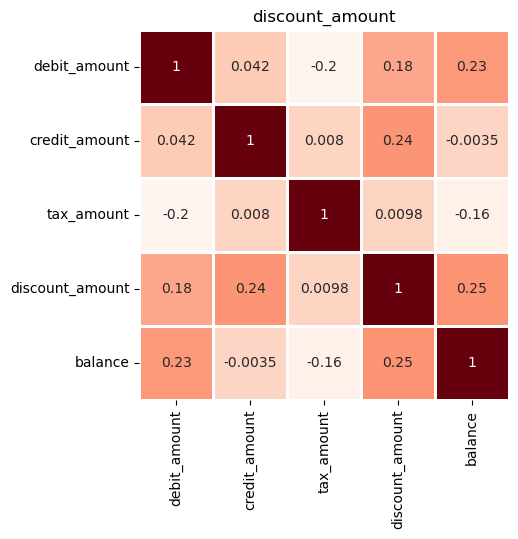

In [10]:
sns.heatmap(correlation,
            annot=True,
            cmap="Reds",
            cbar=False,
            square=True,
            linewidth=1)
plt.title("discount_amount")
plt.show()

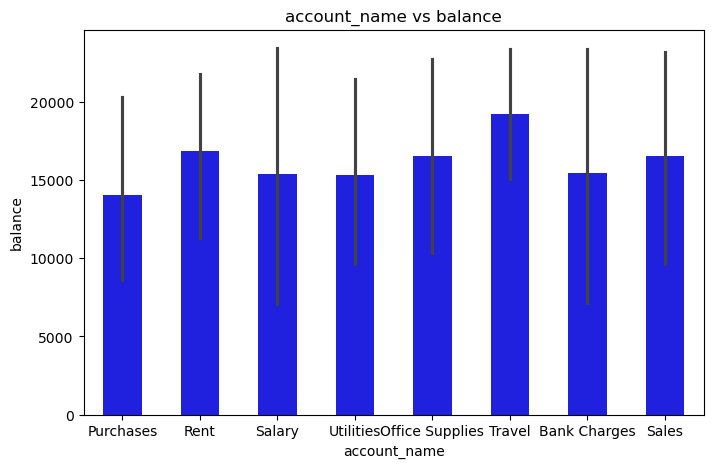

In [11]:
plt.figure(figsize=(8,5))
sns.barplot(data=df,x="account_name",y="balance",width=0.5,color="blue")
plt.title("account_name vs balance")
plt.xlabel("account_name")
plt.ylabel("balance")
plt.show()

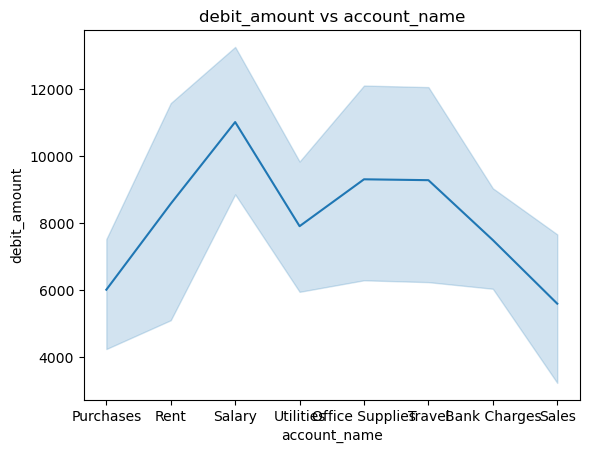

In [12]:
sns.lineplot(x="account_name",y="debit_amount",data=df)
plt.title("debit_amount vs account_name")
plt.show()

In [13]:
data = {
    'Month': ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun'],
    'Budget': [48000, 52000, 58000, 60000, 62000, 68000],
    'Actual': [50000, 55000, 60000, 58000, 65000, 70000],
}

df = pd.DataFrame(data)

print(df)

df_long=df.melt(
    id_vars="Month",
    value_vars=["Budget","Actual"],
    var_name="Type",
    value_name="Amount"
)
df_long

  Month  Budget  Actual
0   Jan   48000   50000
1   Feb   52000   55000
2   Mar   58000   60000
3   Apr   60000   58000
4   May   62000   65000
5   Jun   68000   70000


,Month,Type,Amount
0,Jan,Budget,48000
1,Feb,Budget,52000
2,Mar,Budget,58000
3,Apr,Budget,60000
4,May,Budget,62000
5,Jun,Budget,68000
6,Jan,Actual,50000
7,Feb,Actual,55000
8,Mar,Actual,60000
9,Apr,Actual,58000


<Axes: xlabel='Month', ylabel='Amount'>

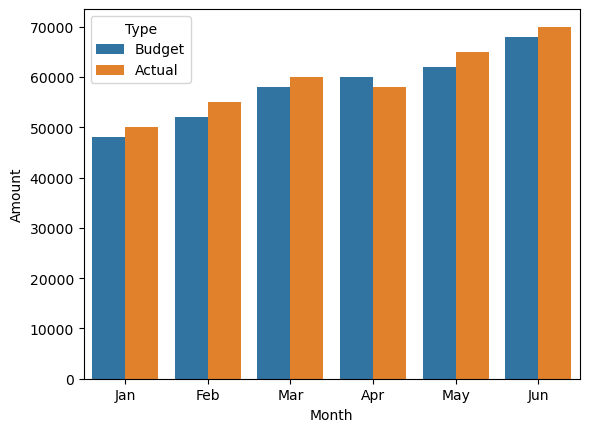

In [14]:
sns.barplot(
    data=df_long,
    x="Month",
    y="Amount",
    hue="Type"
)